# Lab 4 - Image Processing
## Topics: Image Flipping, Intensity Transformation, Bit Plane Slicing

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Set up matplotlib for better visualization
plt.rcParams['figure.figsize'] = (15, 10)
%matplotlib inline

## Task 1: Image Flipping
### 1.1 Vertical Flip Function

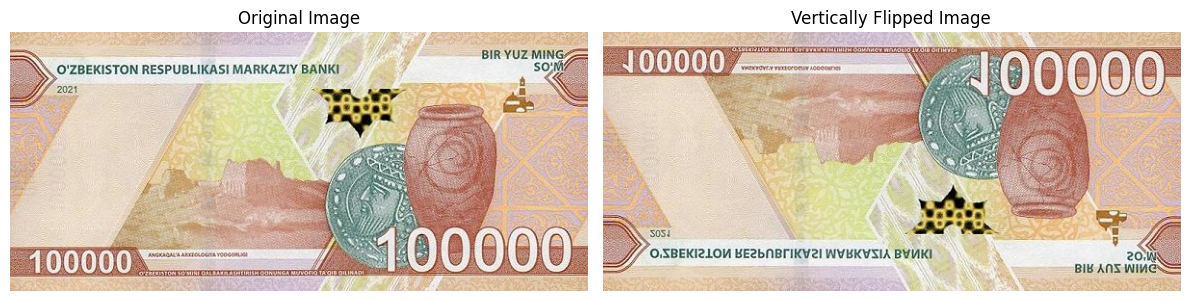

In [11]:
def flip_vertical(image):
    """
    Flips an image vertically (upside down)
    
    Parameters:
    image: input color image
    
    Returns:
    flipped image
    """
    return np.flipud(image)

# Test the function
img = cv2.imread('sum.jpg')
if img is not None:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    flipped = flip_vertical(img_rgb)
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(flipped)
    plt.title('Vertically Flipped Image')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Error: Could not load image")

### 1.2 Mirror Effect Function

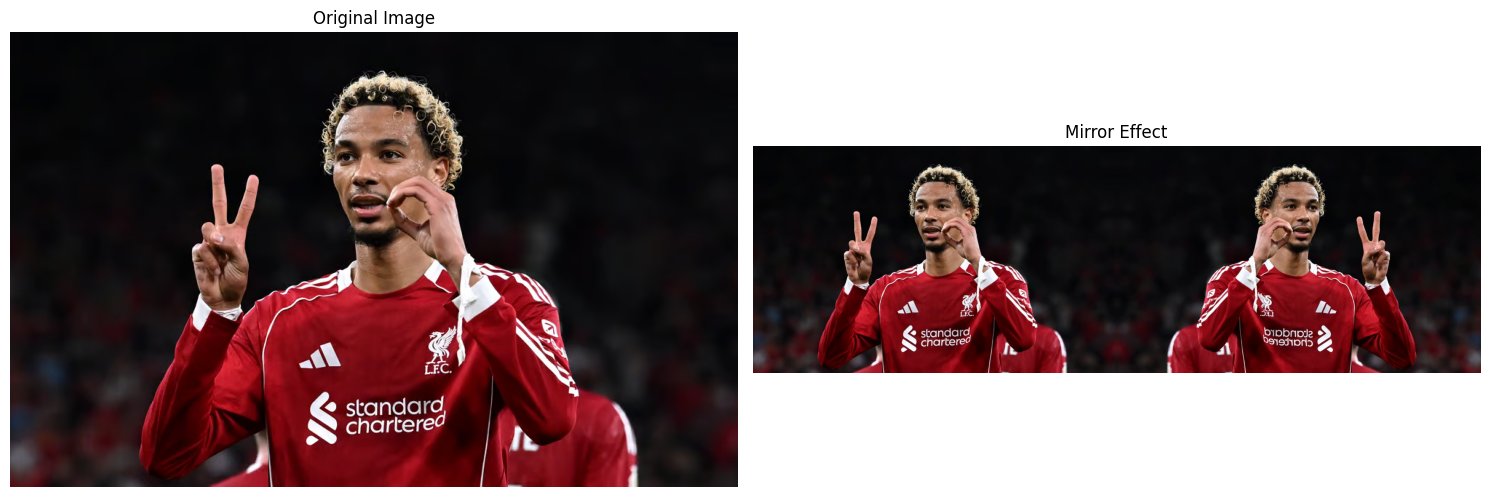

In [3]:
def mirror_effect(image):
    """
    Creates a mirror effect by combining the image with its horizontal flip
    
    Parameters:
    image: input image
    
    Returns:
    mirrored image (double width)
    """
    flipped_horizontal = np.fliplr(image)
    # Concatenate original and flipped image horizontally
    mirrored = np.hstack((image, flipped_horizontal))
    return mirrored

# Test the function
if img is not None:
    mirrored = mirror_effect(img_rgb)
    
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(mirrored)
    plt.title('Mirror Effect')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

## Task 2: Intensity Transformation
### 2.1 Image Negative

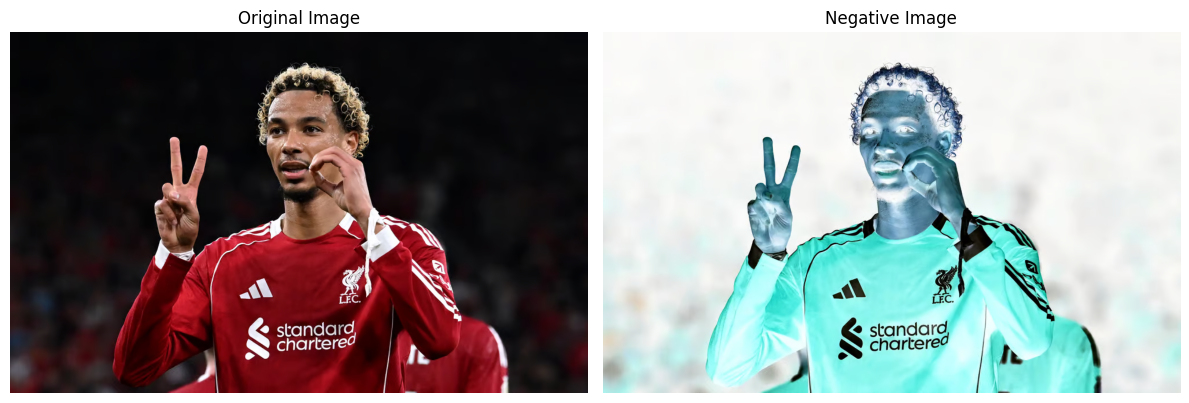

In [4]:
def image_negative(image):
    """
    Performs image negative transformation
    s = L - 1 - r
    
    Parameters:
    image: input image
    
    Returns:
    negative image
    """
    L = 256  # For 8-bit images
    return L - 1 - image

# Test image negative
if img is not None:
    negative = image_negative(img_rgb)
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(negative)
    plt.title('Negative Image')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

### 2.2 Gamma Correction Curves
#### 2.2a Non-normalized (0-255 range)

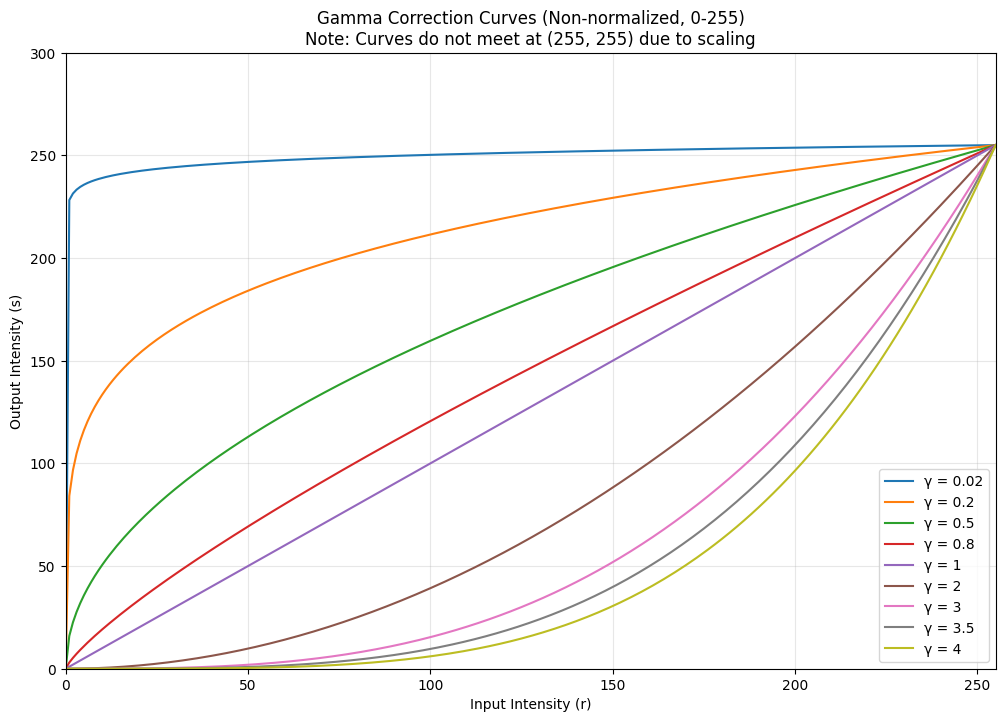

Reason why curves don't meet at y=255:
When using non-normalized values (0-255), the transformation s = c*r^γ requires
different scaling constants (c) for each gamma value to properly map the full range.
Without proper normalization, the curves end at different y values depending on gamma.


In [5]:
# Gamma correction curves for non-normalized image (0-255)
gamma_values = [0.02, 0.2, 0.5, 0.8, 1, 2, 3, 3.5, 4]
x = np.arange(0, 256)

plt.figure(figsize=(12, 8))
for gamma in gamma_values:
    # For non-normalized: s = c * r^gamma, where c is a constant
    # To map 255 to approximately 255, we need c = 255 / (255^gamma)
    c = 255 / (255 ** gamma)
    y = c * (x ** gamma)
    plt.plot(x, y, label=f'γ = {gamma}')

plt.xlabel('Input Intensity (r)')
plt.ylabel('Output Intensity (s)')
plt.title('Gamma Correction Curves (Non-normalized, 0-255)\nNote: Curves do not meet at (255, 255) due to scaling')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim([0, 255])
plt.ylim([0, 300])
plt.show()

print("Reason why curves don't meet at y=255:")
print("When using non-normalized values (0-255), the transformation s = c*r^γ requires")
print("different scaling constants (c) for each gamma value to properly map the full range.")
print("Without proper normalization, the curves end at different y values depending on gamma.")

#### 2.2b Normalized (0-1 range)

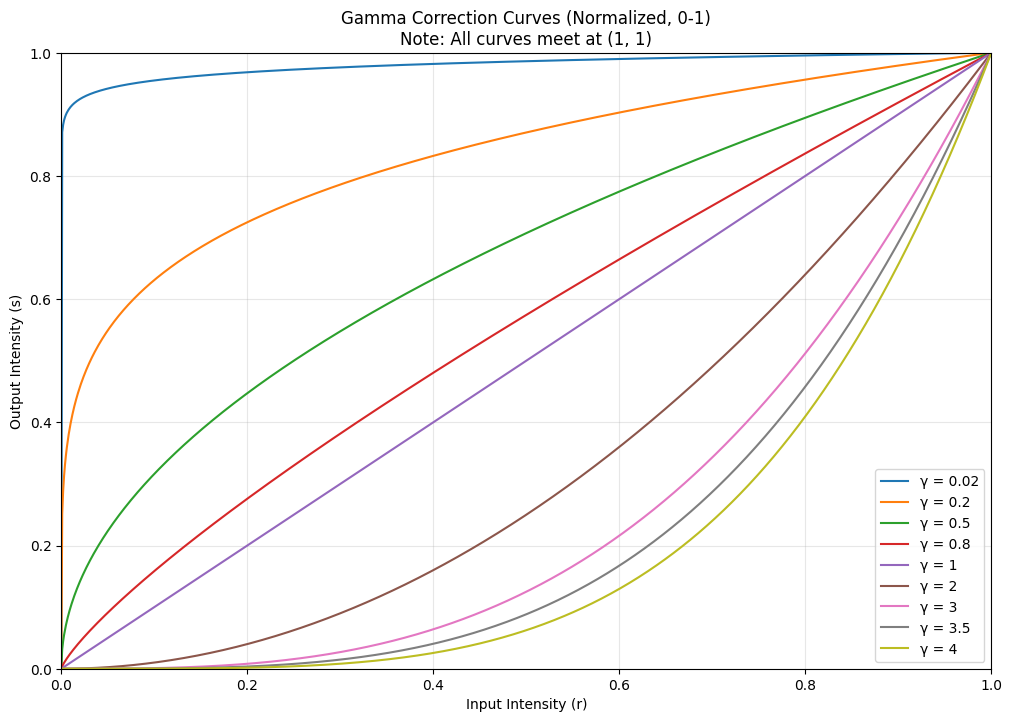

Reason why curves meet at y=1:
With normalized values (0-1), the transformation s = r^γ ensures that:
- When r = 0, s = 0^γ = 0 for all γ > 0
- When r = 1, s = 1^γ = 1 for all γ
Thus, all curves naturally pass through (0,0) and (1,1) regardless of gamma value.


In [6]:
# Gamma correction curves for normalized image (0-1)
x_norm = np.arange(0, 1.001, 0.001)

plt.figure(figsize=(12, 8))
for gamma in gamma_values:
    y_norm = x_norm ** gamma
    plt.plot(x_norm, y_norm, label=f'γ = {gamma}')

plt.xlabel('Input Intensity (r)')
plt.ylabel('Output Intensity (s)')
plt.title('Gamma Correction Curves (Normalized, 0-1)\nNote: All curves meet at (1, 1)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.show()

print("Reason why curves meet at y=1:")
print("With normalized values (0-1), the transformation s = r^γ ensures that:")
print("- When r = 0, s = 0^γ = 0 for all γ > 0")
print("- When r = 1, s = 1^γ = 1 for all γ")
print("Thus, all curves naturally pass through (0,0) and (1,1) regardless of gamma value.")

### 2.3 Apply Gamma Correction to Images

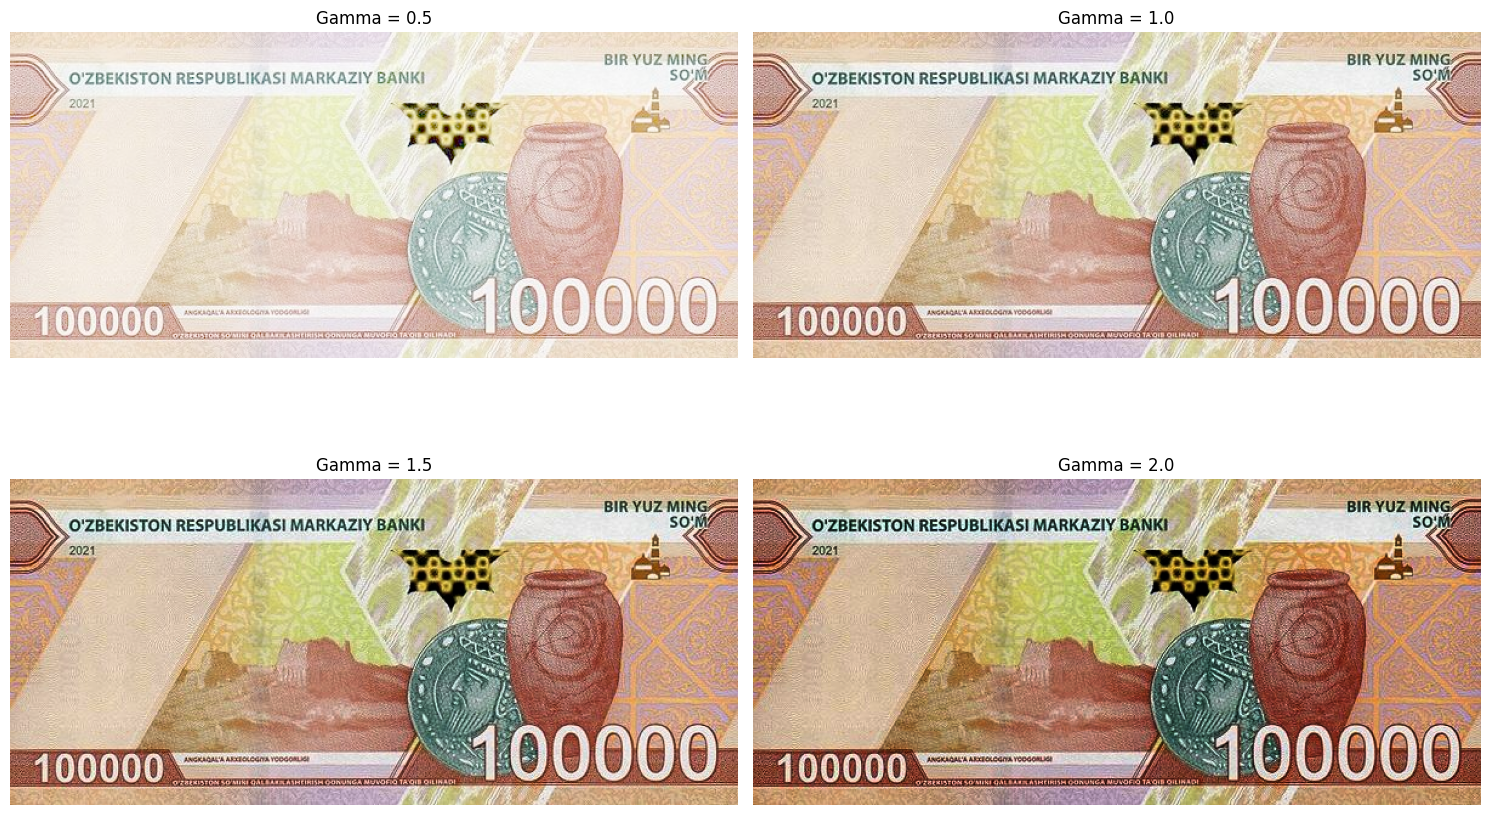

In [14]:
def gamma_correction(image, gamma):
    """
    Apply gamma correction to an image
    
    Parameters:
    image: input image
    gamma: gamma value
    
    Returns:
    gamma corrected image
    """
    # Normalize to [0, 1]
    normalized = image / 255.0
    # Apply gamma correction
    corrected = np.power(normalized, gamma)
    # Scale back to [0, 255]
    return np.uint8(corrected * 255)

# Apply different gamma values
if img is not None:
    test_gammas = [0.5, 1.0, 1.5, 2.0]
    
    plt.figure(figsize=(15, 10))
    for i, gamma in enumerate(test_gammas, 1):
        corrected = gamma_correction(img_rgb, gamma)
        plt.subplot(2, 2, i)
        plt.imshow(corrected)
        plt.title(f'Gamma = {gamma}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

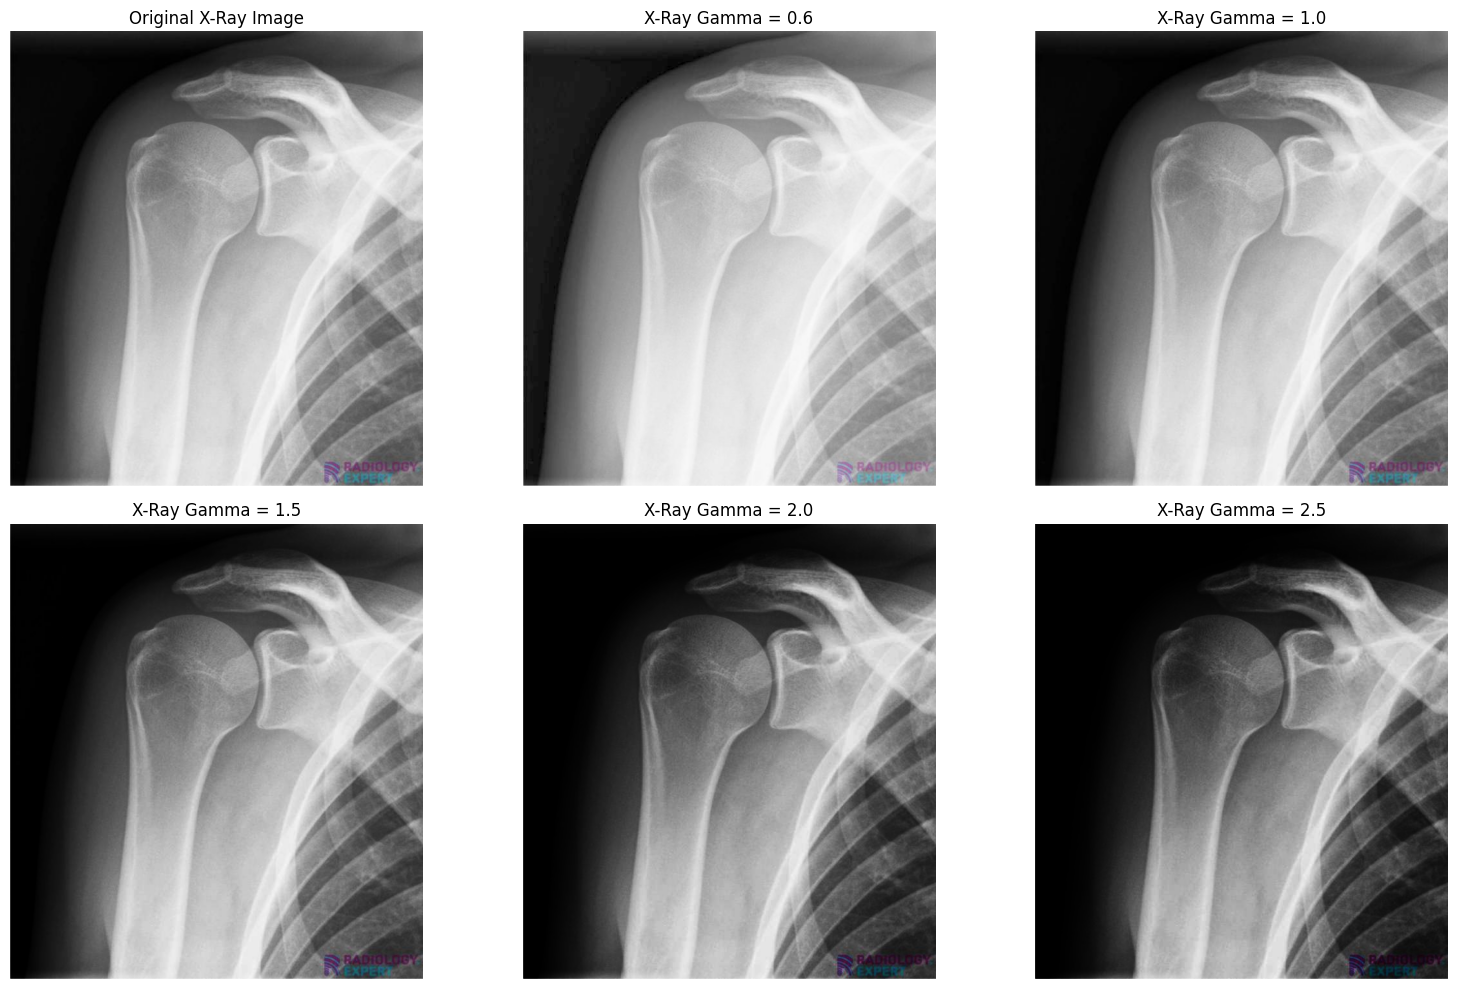

In [15]:

# Apply gamma correction to xray.jpg
xray_img = cv2.imread('xray.jpg')
if xray_img is not None:
    xray_rgb = cv2.cvtColor(xray_img, cv2.COLOR_BGR2RGB)
    test_gammas = [0.4, 0.6, 1.0, 1.5, 2.0, 2.5]
    
    plt.figure(figsize=(16, 10))
    
    # Original image
    plt.subplot(2, 3, 1)
    plt.imshow(xray_rgb)
    plt.title('Original X-Ray Image')
    plt.axis('off')
    
    # Apply different gamma values
    for i, gamma in enumerate(test_gammas, 1):
        if i == 1:
            continue  # Skip first position since we showed original
        corrected = gamma_correction(xray_rgb, gamma)
        plt.subplot(2, 3, i)
        plt.imshow(corrected)
        plt.title(f'X-Ray Gamma = {gamma}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Error: Could not load xray.jpg")


### 2.4 Intensity Range Highlighting

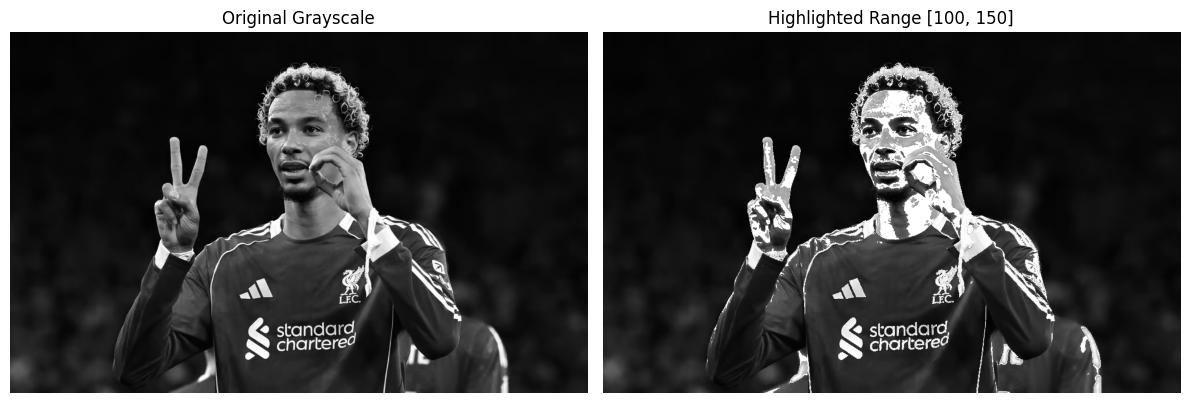

In [8]:
def highlight_intensity_range(image, A, B, L=256):
    """
    Assign L-1 to intensities in the range [A, B]
    
    Parameters:
    image: input grayscale image
    A: lower bound of intensity range
    B: upper bound of intensity range
    L: number of intensity levels (default 256)
    
    Returns:
    image with highlighted intensity range
    """
    result = image.copy()
    # Find indices where intensities fall in range [A, B]
    mask = (image >= A) & (image <= B)
    result[mask] = L - 1
    return result

# Test the function on grayscale version
if img is not None:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Highlight intensity range [100, 150]
    highlighted = highlight_intensity_range(gray, 100, 150)
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(gray, cmap='gray')
    plt.title('Original Grayscale')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(highlighted, cmap='gray')
    plt.title('Highlighted Range [100, 150]')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

### 2.5 Contrast Stretching

/var/folders/7z/pkj48l4n56db93wwt59h04br0000gn/T/ipykernel_41804/1728266350.py:37: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(gray.ravel(), 256, [0, 256], alpha=0.5, label='Original')
/var/folders/7z/pkj48l4n56db93wwt59h04br0000gn/T/ipykernel_41804/1728266350.py:38: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(stretched.ravel(), 256, [0, 256], alpha=0.5, label='Stretched')


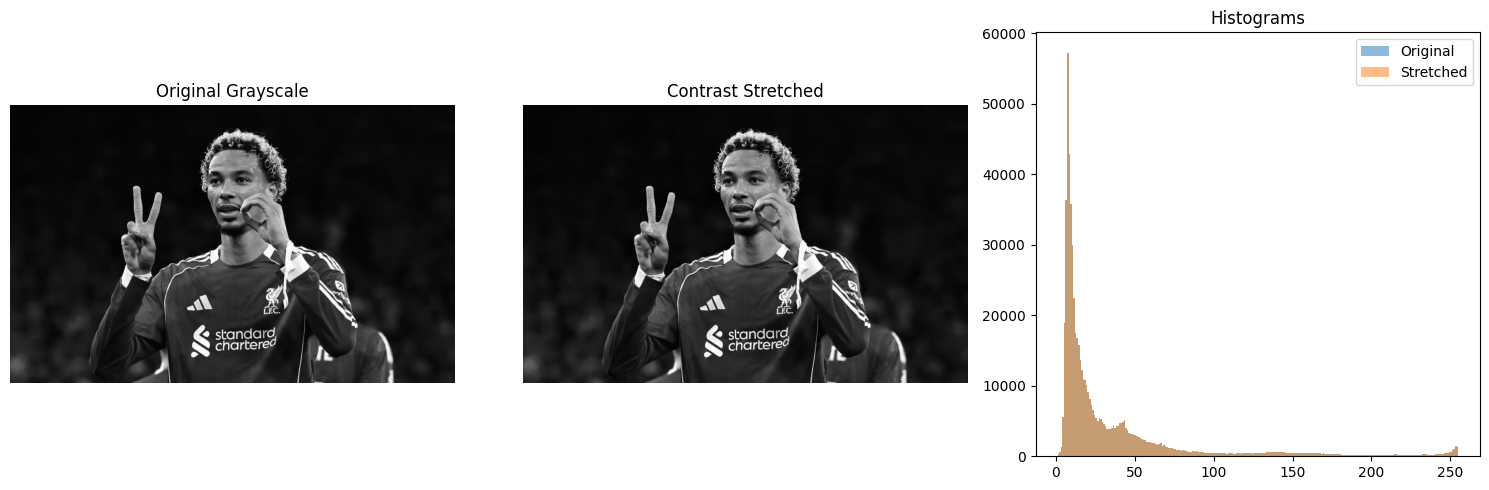

In [9]:
def contrast_stretching(image):
    """
    Apply contrast stretching to enhance image
    
    Parameters:
    image: input image
    
    Returns:
    contrast stretched image
    """
    # Find min and max intensities
    min_val = np.min(image)
    max_val = np.max(image)
    
    # Apply contrast stretching formula
    stretched = ((image - min_val) / (max_val - min_val)) * 255
    return np.uint8(stretched)

# Test contrast stretching
if img is not None:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    stretched = contrast_stretching(gray)
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(gray, cmap='gray')
    plt.title('Original Grayscale')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(stretched, cmap='gray')
    plt.title('Contrast Stretched')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.hist(gray.ravel(), 256, [0, 256], alpha=0.5, label='Original')
    plt.hist(stretched.ravel(), 256, [0, 256], alpha=0.5, label='Stretched')
    plt.title('Histograms')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

## Task 3: Bit-Plane Slicing
### Display All 8 Bit Planes

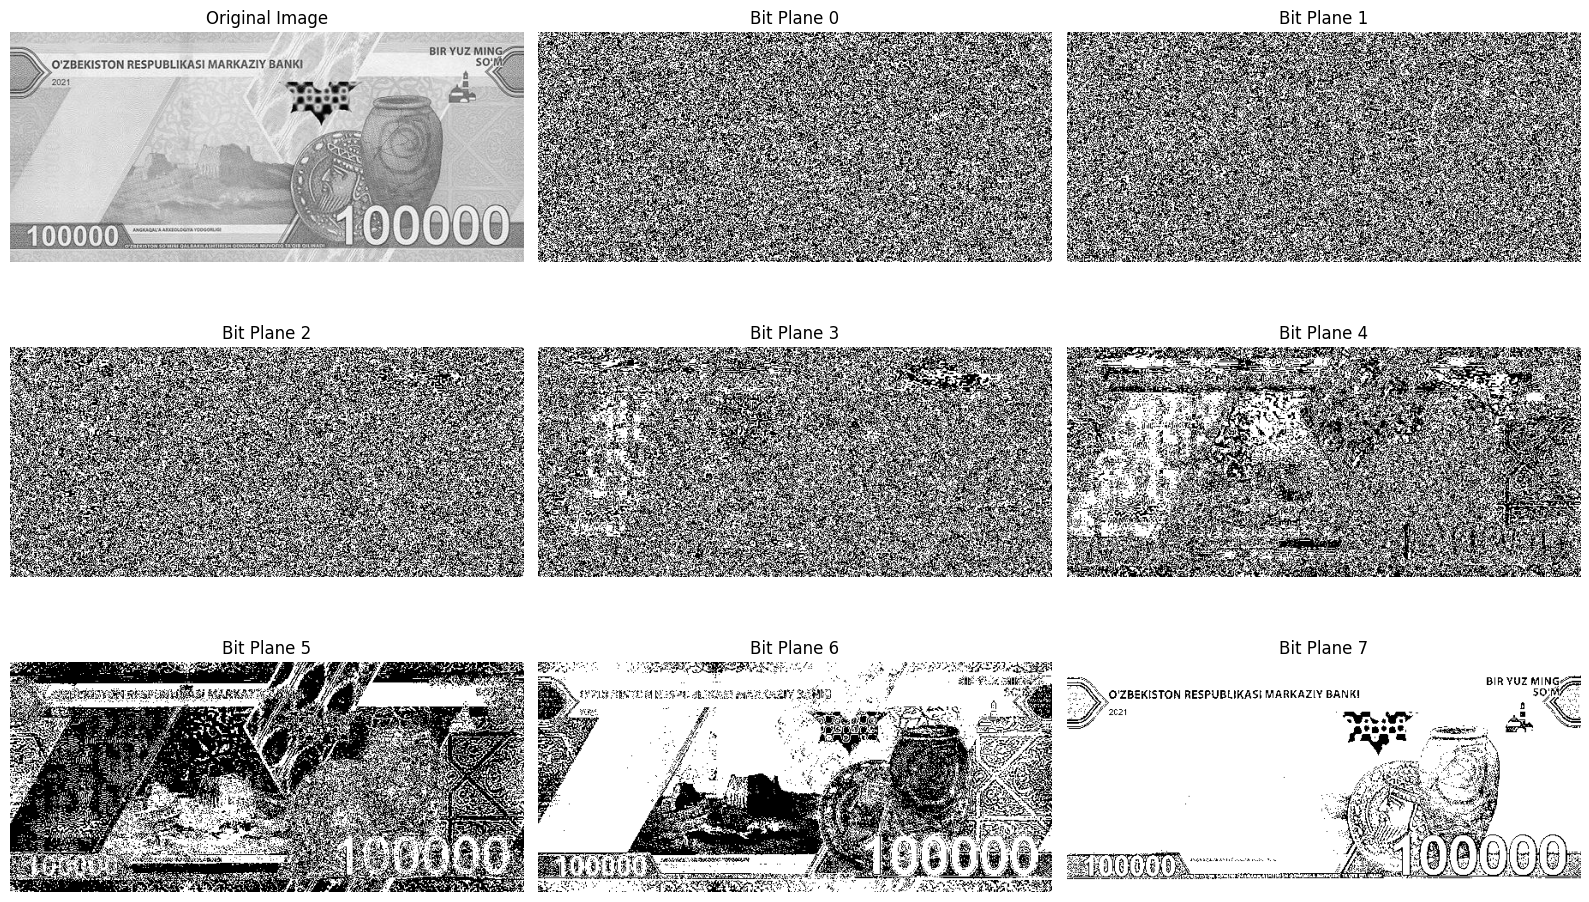

Bit Plane Analysis:
- Bit 7 (MSB): Contains most visual information
- Bit 6-5: Contains significant structural information
- Bit 4-3: Contains moderate detail
- Bit 2-0 (LSB): Contain least information, appear noisy


In [12]:
def displayBitResponse(image):
    """
    Display all 8 bit planes of a grayscale image
    
    Parameters:
    image: input grayscale image
    """
    plt.figure(figsize=(16, 10))
    
    # Display original image
    plt.subplot(3, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    
    # Extract and display each bit plane (from bit 0 to bit 7)
    for bit in range(8):
        # Extract the bit plane using bitwise operations
        bit_plane = ((image >> bit) & 1) * 255
        
        plt.subplot(3, 3, bit + 2)
        plt.imshow(bit_plane, cmap='gray')
        plt.title(f'Bit Plane {bit}')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Additional analysis
    print("Bit Plane Analysis:")
    print("- Bit 7 (MSB): Contains most visual information")
    print("- Bit 6-5: Contains significant structural information")
    print("- Bit 4-3: Contains moderate detail")
    print("- Bit 2-0 (LSB): Contain least information, appear noisy")

# Test the function
if img is not None:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    displayBitResponse(gray)

### Bit Plane Reconstruction

In [ ]:
def reconstruct_from_bit_planes(image, start_bit, end_bit):
    """
    Reconstruct image using selected bit planes
    
    Parameters:
    image: input grayscale image
    start_bit: starting bit plane (0-7)
    end_bit: ending bit plane (0-7)
    
    Returns:
    reconstructed image
    """
    result = np.zeros_like(image)
    
    for bit in range(start_bit, end_bit + 1):
        bit_plane = ((image >> bit) & 1)
        result = result | (bit_plane << bit)
    
    return result

# Test reconstruction with different bit plane combinations
if img is not None:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    plt.figure(figsize=(15, 10))
    
    # Original
    plt.subplot(2, 3, 1)
    plt.imshow(gray, cmap='gray')
    plt.title('Original (All 8 bits)')
    plt.axis('off')
    
    # Using only MSB (bit 7)
    plt.subplot(2, 3, 2)
    plt.imshow(reconstruct_from_bit_planes(gray, 7, 7), cmap='gray')
    plt.title('Bit 7 only (MSB)')
    plt.axis('off')
    
    # Using bits 7-6
    plt.subplot(2, 3, 3)
    plt.imshow(reconstruct_from_bit_planes(gray, 6, 7), cmap='gray')
    plt.title('Bits 7-6')
    plt.axis('off')
    
    # Using bits 7-5
    plt.subplot(2, 3, 4)
    plt.imshow(reconstruct_from_bit_planes(gray, 5, 7), cmap='gray')
    plt.title('Bits 7-5')
    plt.axis('off')
    
    # Using bits 7-4
    plt.subplot(2, 3, 5)
    plt.imshow(reconstruct_from_bit_planes(gray, 4, 7), cmap='gray')
    plt.title('Bits 7-4')
    plt.axis('off')
    
    # Using only LSBs (bits 0-2)
    plt.subplot(2, 3, 6)
    plt.imshow(reconstruct_from_bit_planes(gray, 0, 2), cmap='gray')
    plt.title('Bits 0-2 (LSBs only)')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

## Summary

This notebook covers:
1. **Image Flipping**: Vertical flip and mirror effects
2. **Intensity Transformation**: 
   - Image negative
   - Gamma correction with curve plotting (normalized and non-normalized)
   - Intensity range highlighting
   - Contrast stretching
3. **Bit-Plane Slicing**: Displaying and analyzing all 8 bit planes and reconstruction